# 🔧 Environment Setup

Install core libraries for fine-tuning BioClinical ModernBERT on a symptom→disease classification task.

**Main Packages**
- `transformers` – model + Trainer utilities
- `datasets` – dataset loading & mapping
- `torch` – deep learning backend
- `scikit-learn` – metrics & evaluation
- `optuna` – hyperparameter optimization
- `evaluate` – standardized metric interface
- `wandb` – experiment tracking (optional)
- `pandas`, `numpy` – data manipulation
- `matplotlib`, `seaborn` – plotting

Run the install cell below once (reuse cached env afterwards). Keep dependencies minimal to reduce startup time.

In [1]:
%pip install transformers datasets torch scikit-learn kagglehub pandas numpy keras matplotlib seaborn nbformat optuna evaluate wandb "wandb[core]" accelerate

Note: you may need to restart the kernel to use updated packages.


In [2]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/notlath/.netrc.
wandb: Currently logged in as: qltpagsuguiron (qltpagsuguiron-technological-institute-of-the-philippines) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# 📊 Dataset Preprocessing

Prepare the symptom→disease dataset for supervised classification.

**Steps**
1. Load filtered English dataset from Hugging Face.
2. Keep only `text` (symptom description) + `label` (disease).
3. Build **sorted** `label2id` / `id2label` mappings for deterministic encoding; convert labels to integer `labels` field.
4. **Stratified** split: 70% train / 15% validation / 15% test (seed=42 for reproducibility).
5. Store splits in a HF `DatasetDict` for seamless downstream use.

Outputs:
- Clean splits in `dataset` (`DatasetDict` with keys: `train`, `validation`, `test`).
- Deterministic integer label space used throughout training & evaluation.

In [3]:
from datasets import load_dataset, ClassLabel
from transformers import set_seed

set_seed(42)

# Load the pre-split dataset from Hugging Face
# dataset will contain 'train' (2100), 'validation' (450), 'test' (450)
dataset = load_dataset("notlath/eng_dataset")

# Map over everything (this applies to all 3 splits automatically)
def preprocess_labels(example):
    return {
        'text': example['text'],
        'label': example['label']
    }

dataset = dataset.map(preprocess_labels)

# Get unique labels from the train split to build ID mappings
unique_labels = sorted(set(dataset['train']['label']))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

# Convert string labels to numerical IDs (applies to all splits automatically)
def convert_labels_to_ids(example):
    return {
        'text': example['text'],
        'labels': label2id[example['label']]
    }

dataset = dataset.map(convert_labels_to_ids, remove_columns=['label'])

# Cast numerical labels feature to ClassLabel representation
dataset = dataset.cast_column(
    "labels", ClassLabel(names=unique_labels)
)

# Done! No more manual splitting.
print(dataset)

/home/notlath/Downloads/model-training/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 2100
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 450
    })
})


In [4]:
print("Dataset columns:")
print(dataset['train'].column_names)
print("\nFirst few examples from train dataset:")
for i in range(3):
    print(f"Example {i}: {dataset['train'][i]}")

Dataset columns:
['text', 'labels']

First few examples from train dataset:
Example 0: {'text': 'A severe febrile state, combined with a harsh, barking cough and an emerging erythematous eruption on my face and neck, has left me incapacitated. My articulations feel rigid, and my eyes are inflamed, exhibiting significant lacrimation and stinging sensations.', 'labels': 3}
Example 1: {'text': 'Yesterday while relaxing, I developed mild stomach cramping. Since then, I have experienced three episodes of loose, watery output, which is quite abnormal for me. I feel deeply fatigued, have a mild headache, and a slight temperature. It is incredibly disruptive. The stress of managing this, along with the chronic lack of rest due to my digestive issues, has left me unable to focus on any professional obligations today.', 'labels': 1}
Example 2: {'text': 'Since yesterday evening, I have been incapacitated by a sudden, intense spike in body temperature, paired with a persistent, non-productive coug

In [5]:
print("Dataset structure:")
print(dataset)
print("\nSample data from train:")
print(dataset["train"][0])
print(f"Type of text field: {type(dataset['train'][0]['text'])}")
print(f"Text content: {dataset['train'][0]['text']}")

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 2100
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 450
    })
})

Sample data from train:
{'text': 'A severe febrile state, combined with a harsh, barking cough and an emerging erythematous eruption on my face and neck, has left me incapacitated. My articulations feel rigid, and my eyes are inflamed, exhibiting significant lacrimation and stinging sensations.', 'labels': 3}
Type of text field: <class 'str'>
Text content: A severe febrile state, combined with a harsh, barking cough and an emerging erythematous eruption on my face and neck, has left me incapacitated. My articulations feel rigid, and my eyes are inflamed, exhibiting significant lacrimation and stinging sensations.


In [6]:
def check_overlap(split1, split2, name1, name2):
    """Check for overlapping text samples between two splits."""
    set1 = set(split1['text'])
    set2 = set(split2['text'])
    overlap = set1.intersection(set2)

    if overlap:
        print(f"❌ WARNING: {len(overlap)} overlapping samples between {name1} and {name2}")
        for idx, sample in enumerate(sorted(overlap), 1):
            print(f"   {idx}. {sample}")
        return len(overlap)
    else:
        print(f"✅ No overlap between {name1} and {name2}")
        return 0

print("Checking for data leakage...\n")
total_overlap = 0
total_overlap += check_overlap(dataset['train'], dataset['validation'], 'train', 'validation')
total_overlap += check_overlap(dataset['train'], dataset['test'], 'train', 'test')
total_overlap += check_overlap(dataset['validation'], dataset['test'], 'validation', 'test')

if total_overlap == 0:
    print(f"\n✅ Data integrity verified: No leakage detected!")
else:
    print(f"\n❌ Total overlapping samples: {total_overlap}")


Checking for data leakage...

✅ No overlap between train and validation
✅ No overlap between train and test
✅ No overlap between validation and test

✅ Data integrity verified: No leakage detected!


In [7]:
# Check duplicate samples by text within each split and across all splits
def report_duplicates(ds, split_name):
    texts = ds["text"]
    total = len(texts)
    unique = len(set(texts))
    dup_count = total - unique
    
    print(f"[{split_name}] total={total}, unique={unique}, duplicates={dup_count}")
    if dup_count > 0:
        seen = set()
        dups = []
        for t in texts:
            if t in seen:
                dups.append(t)
            else:
                seen.add(t)
        print(f"  Sample duplicate texts (up to 5):")
        for x in list(dict.fromkeys(dups))[:5]:
            print(f"   - {x[:200]}{'...' if len(x) > 200 else ''}")

print("Checking duplicates within each split:\n")
for split_name, split_data in dataset.items():
    report_duplicates(split_data, split_name)

print("\nChecking duplicates across all splits:")
all_texts = {
    "text": list(dataset["train"]["text"])
    + list(dataset["validation"]["text"])
    + list(dataset["test"]["text"])
}
report_duplicates(all_texts, "all_splits_combined")

Checking duplicates within each split:

[train] total=2100, unique=2100, duplicates=0
[validation] total=450, unique=450, duplicates=0
[test] total=450, unique=450, duplicates=0

Checking duplicates across all splits:
[all_splits_combined] total=3000, unique=3000, duplicates=0


# 🤖 Model Setup & Tokenization

**Model**: `thomas-sounack/BioClinical-ModernBERT-base` (domain‑adapted BERT variant for clinical/biomedical text).

**Tokenization**
- Apply tokenizer to all splits with truncation only (no static padding).
- **Dynamic padding** is applied at batch time via `DataCollatorWithPadding`, reducing wasted computation.
- Remove raw `text` after encoding; retain `input_ids`, `attention_mask`, `labels`.

**Goal**: Produce variable-length encoded sequences; actual padding deferred to the data collator.

Result: `tokenized_dataset` mirrors original splits with encoded features.

In [8]:
from transformers import AutoTokenizer

model_id = "thomas-sounack/BioClinical-ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        # padding handled dynamically by DataCollatorWithPadding at batch time
    )

# Apply tokenize to each dataset split
tokenized_dataset = {}
for split, data in dataset.items():
    tokenized_dataset[split] = data.map(tokenize, batched=True, remove_columns=["text"])

print(tokenized_dataset)
print("Features:", tokenized_dataset["train"].features.keys())

Map: 100%|██████████| 450/450 [00:00<00:00, 23297.66 examples/s]

{'train': Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2100
}), 'validation': Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 450
}), 'test': Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 450
})}
Features: dict_keys(['labels', 'input_ids', 'attention_mask'])


In [9]:
from transformers import AutoModelForSequenceClassification

unique_labels = tokenized_dataset["train"].unique("labels")
num_labels = len(unique_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=num_labels, label2id=label2id, id2label=id2label,
)

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 492.69it/s, Materializing param=model.layers.21.mlp_norm.weight]    
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# 🔍 Hyperparameter Optimization

Optimize training for validation accuracy using Optuna (TPE sampler, persistent SQLite storage).

**Objective**: Maximize `eval_accuracy`.

**Fixed Regularization**: All dropout variants set to 0.1.

**Search Space**
- Learning rate: log-uniform [1e-6, 1e-3]
- Train batch size: {16, 32}
- Weight decay: uniform [0.01, 0.4]

**Enhancements**
- **20 Optuna trials** for broader exploration.
- **Gradient accumulation** (2 steps) for effective larger batches.
- **Mixed precision** (bf16) for faster training.
- **Early stopping** (patience=3) to prune bad trials.

**Process**
1. `model_init` supplies fresh model each trial (ensures comparable starts).
2. Trainer runs one configuration → records accuracy, F1, precision, recall.
3. Best trial exported to `hyperparameters.txt` for reuse.

Result: `best_run` object with chosen LR, batch size, weight decay.

In [10]:
import optuna
from optuna.storages import RDBStorage
from optuna.samplers import TPESampler

sampler = TPESampler(seed=42)

# Define persistent storage
storage = RDBStorage("sqlite:///optuna_trials.db")

study = optuna.create_study(
    study_name="transformers_optuna_study", direction="maximize", storage=storage, load_if_exists=True, sampler=sampler
)

[I 2026-04-03 18:10:02,015] A new study created in RDB with name: transformers_optuna_study


In [11]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = eval_pred.predictions.argmax(axis=-1)
    labels = eval_pred.label_ids
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    precision = precision_score(labels, predictions, average="macro")
    recall = recall_score(labels, predictions, average="macro")
    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
    }

def compute_objective(metrics):
    return metrics["eval_accuracy"]

In [12]:
from transformers import (
    Trainer, TrainingArguments, DataCollatorWithPadding,
    AutoModelForSequenceClassification, AutoTokenizer, EarlyStoppingCallback,
)

model_id = "thomas-sounack/BioClinical-ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

unique_labels = dataset["train"].unique("labels")
num_labels = len(unique_labels)

training_args = TrainingArguments(
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    num_train_epochs=5,
    weight_decay=0.01,
    bf16=True,
    seed=42,
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1, # Important: limit checkpoints to save disk space
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="wandb",
    logging_dir="./logs",
    run_name="transformers_optuna_study",
)

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 1e-3, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8]),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.4),
    }

def model_init(trial=None):
    import torch
    import gc
    # Clean up GPU memory between trials
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=num_labels,
        label2id=label2id,
        id2label=id2label,
        attention_dropout=0.0,
        mlp_dropout=0.0,
        embedding_dropout=0.0,
        classifier_dropout=0.0,
    )

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1455.75it/s, Materializing param=model.layers.21.mlp_norm.weight]     
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=20,
    compute_objective=compute_objective,
    study_name="transformers_optuna_study",
    storage="sqlite:///optuna_trials.db",
    load_if_exists=True,
)

print(best_run)

[I 2026-04-03 18:10:06,247] Using an existing study with name 'transformers_optuna_study' instead of creating a new one.
Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1464.09it/s, Materializing param=model.layers.21.mlp_norm.weight]    
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/notlath/.netrc.
wandb: Currently logged in as: qltpagsuguiron (qltpagsuguiron-technological-institute-of-the-philippines) to https://api.wandb.ai. Use `wandb lo

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,10.514018,0.433385,0.882222,0.884874,0.912505,0.882222
2,1.428604,0.060572,0.977778,0.977669,0.977877,0.977778
3,0.666244,0.051000,0.986667,0.986694,0.986952,0.986667
4,0.200722,0.042798,0.984444,0.984546,0.984848,0.984444
5,0.023150,0.027738,0.984444,0.984471,0.984755,0.984444


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]
[I 2026-04-03 18:11:35,504] Trial 0 finished with value: 0.9844444444444445 and parameters: {'learning_rate': 0.00031177681613370174, 'per_device_train_batch_size': 8, 'weight_decay': 0.20414126276676342}. Best is trial 0 with value: 0.9844444444444445.
Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1396.30it/s, Materializing param=model.layers.21.mlp_norm.weight]    
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


eval/accuracy,▁▇███
eval/f1_macro,▁▇███
eval/loss,█▂▁▁▁
eval/precision_macro,▁▇███
eval/recall_macro,▁▇███
eval/runtime,▁▃█▁▁
eval/samples_per_second,█▆▁██
eval/steps_per_second,█▆▁██
train/epoch,▁▁▃▃▅▅▆▆███
train/global_step,▁▁▃▃▅▅▆▆███
+3,...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,7.761581,0.224024,0.933333,0.933811,0.936821,0.933333
2,0.983313,0.082275,0.975556,0.975538,0.975784,0.975556
3,0.235838,0.083185,0.975556,0.975652,0.976234,0.975556
4,0.032157,0.078222,0.980000,0.980041,0.980367,0.980000
5,0.009831,0.073572,0.982222,0.982248,0.982558,0.982222


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]
[I 2026-04-03 18:31:18,834] Trial 18 pruned. 
Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1440.39it/s, Materializing param=model.layers.21.mlp_norm.weight]     
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


eval/accuracy,█▁
eval/f1_macro,█▁
eval/loss,▁█
eval/precision_macro,█▁
eval/recall_macro,█▁
eval/runtime,▁█
eval/samples_per_second,█▁
eval/steps_per_second,█▁
train/epoch,▁▁██
train/global_step,▁▁██
+3,...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,14.419626,1.711962,0.335556,0.310809,0.306245,0.335556


[I 2026-04-03 18:31:47,395] Trial 19 pruned. 


BestRun(run_id='4', objective=0.9955555555555555, hyperparameters={'learning_rate': 0.0003385381746308142, 'per_device_train_batch_size': 4, 'weight_decay': 0.06673774688505733}, run_summary=None)


In [14]:
from pprint import pprint

# Write the best hyperparameters to a file
with open("hyperparameters.txt", "w") as f:
    for key, value in best_run.hyperparameters.items():
        f.write(f"{key}: {value}\n")

print("Best hyperparameters saved to hyperparameters.txt")
print("\nBest Hyperparameters:")
pprint(best_run.hyperparameters)

Best hyperparameters saved to hyperparameters.txt

Best Hyperparameters:
{'learning_rate': 0.0003385381746308142,
 'per_device_train_batch_size': 4,
 'weight_decay': 0.06673774688505733}


# 🎯 Final Model Training

Train with best hyperparameters and enhanced stability settings.

**Core Settings**
- Epochs: 10 (extended training)
- Batch size: Optuna-selected | gradient accumulation: 2 steps
- Learning rate: Optuna-selected + cosine schedule + 10% warmup
- Weight decay: Optuna-selected
- Label smoothing: 0.1 | Gradient clipping: 1.0
- Dropout: attention / mlp / embedding / classifier = 0.1
- **Mixed precision** (bf16) for throughput
- **Early stopping** (patience=3) to prevent overfitting

**Trainer Features**
- `load_best_model_at_end` + F1-macro selection
- Epoch-level eval + checkpoint pruning (`save_total_limit=2`)
- Tracks accuracy, F1, precision, recall per epoch
- Weights & Biases tracking
- Hub-ready (`hub_model_id` set)

Outcome: `extended_final_model` directory containing the best fine‑tuned weights.

In [15]:
# import shutil
# import os

# folder_path = "./results"
# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)
#     print(f"Removed folder: {folder_path}")
# else:
#     print(f"Folder not found: {folder_path}")

In [16]:
from transformers import (
    Trainer, TrainingArguments, AutoModelForSequenceClassification,
    DataCollatorWithPadding, EarlyStoppingCallback,
)

model_id = "thomas-sounack/BioClinical-ModernBERT-base"

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    attention_dropout=0.0,
    mlp_dropout=0.0,
    embedding_dropout=0.0,
    classifier_dropout=0.0,
)

# Calculate warmup from effective batch size (incl. accumulation)
effective_batch = best_run.hyperparameters["per_device_train_batch_size"] * 8  # gradient_accumulation_steps=8
steps_per_epoch = len(tokenized_dataset["train"]) // effective_batch
total_steps = steps_per_epoch * 10
warmup_steps = int(total_steps * 0.1)

training_args = TrainingArguments(
    output_dir="./extended_final_model",

    # Optuna-optimized hyperparameters
    per_device_train_batch_size=best_run.hyperparameters["per_device_train_batch_size"],
    learning_rate=best_run.hyperparameters["learning_rate"],
    weight_decay=best_run.hyperparameters["weight_decay"],

    # Training configuration
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    gradient_accumulation_steps=8,
    bf16=True,

    # Optimization
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    label_smoothing_factor=0.1,
    max_grad_norm=1.0,

    # Checkpoint & evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,

    # Logging & tracking
    logging_strategy="epoch",
    report_to="wandb",
    run_name="final_training_optimized_hyperparams",

    # Hugging Face integration
    hub_model_id="notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42",

    # Reproducibility
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1312.76it/s, Materializing param=model.layers.21.mlp_norm.weight]    
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,7.343914,0.508481,0.980000,0.980153,0.980833,0.980000
2,4.249107,0.509613,0.973333,0.973679,0.975744,0.973333
3,3.863628,0.508703,0.968889,0.968654,0.969699,0.968889
4,3.669215,0.521472,0.951111,0.951102,0.956679,0.951111


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]


TrainOutput(global_step=264, training_loss=4.781465934984611, metrics={'train_runtime': 104.0036, 'train_samples_per_second': 201.916, 'train_steps_per_second': 6.346, 'total_flos': 458201562451056.0, 'train_loss': 4.781465934984611, 'epoch': 4.0})

# 🚀 Deployment to Hugging Face Hub

Publish the fine‑tuned model for reuse and transparency.

**Repo**: `notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42`

**Steps**
1. Authenticate with a secure Hugging Face token (never hard‑code in shared notebooks; use env var or input prompt).
2. Call `trainer.push_to_hub()` (auto‑uploads model + tokenizer + config).
3. If that fails, manually load from `final_model_train/` and push model + tokenizer.
4. Verify `config.json` lists all dropout params (attention, mlp, embedding, classifier = 0.1).

**Post‑Upload Checklist**
- Model card updated (add task, dataset citation, metrics, limitations).
- License + intended use documented.
- Example inference snippet works via `pipeline()`.

Outcome: Public, reproducible artifact ready for downstream evaluation.

In [ ]:
from huggingface_hub import login

# Paste your token here - Get from https://huggingface.co/settings/tokens
token = ""  # Replace with your actual token
login(token=token)

# Verify it worked
from huggingface_hub import whoami
try:
    user = whoami()
    print(f"✅ Logged in as: {user['name']}")
except Exception as e:
    print(f"❌ Login failed: {e}")

# Push model using trainer.push_to_hub() - this ensures the trained model is pushed
repo_name = "notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42"

print("🚀 Pushing model to Hugging Face...")
try:
    # Method 1: Use trainer.push_to_hub() (recommended)
    trainer.push_to_hub(repo_name, token=token)
    print(f"✅ Successfully pushed model using trainer.push_to_hub() to {repo_name}")
except Exception as e:
    print(f"❌ trainer.push_to_hub() failed: {e}")
    print("🔄 Trying alternative method...")

    # Method 2: Alternative - push model and tokenizer directly from memory
    try:
        # Push the model and tokenizer directly from the trainer's memory
        # (The folder method failed because the folder isn't saved until later in the notebook)
        trainer.model.push_to_hub(repo_name, token=token)
        tokenizer.push_to_hub(repo_name, token=token)
        print(f"✅ Successfully pushed model using alternative method to {repo_name}")

    except Exception as e2:
        print(f"❌ Alternative method also failed: {e2}")

print("\n📋 Verify your model config includes all dropout parameters:")
print("Visit: https://huggingface.co/" + repo_name + "/blob/main/config.json")

# Load the model config to get actual dropout values
from transformers import AutoConfig
try:
    # Try to load from the pushed model on HuggingFace
    config = AutoConfig.from_pretrained(repo_name)
    print("✅ Loaded config from HuggingFace Hub")
except:
    # Fallback to local model memory if HuggingFace fails
    config = trainer.model.config
    print("✅ Loaded config from local model")

print("Actual dropout parameters:")
print(f"- attention_dropout: {getattr(config, 'attention_dropout', 'Not found')}")
print(f"- mlp_dropout: {getattr(config, 'mlp_dropout', 'Not found')}")
print(f"- embedding_dropout: {getattr(config, 'embedding_dropout', 'Not found')}")
print(f"- classifier_dropout: {getattr(config, 'classifier_dropout', 'Not found')}")

# Also show hidden_dropout_prob if available (common BERT parameter)
if hasattr(config, 'hidden_dropout_prob'):
    print(f"- hidden_dropout_prob: {config.hidden_dropout_prob}")

✅ Logged in as: notlath
🚀 Pushing model to Hugging Face...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]
Processing Files (2 / 2): 100%|██████████|  598MB /  598MB, 7.39MB/s  
New Data Upload: 100%|██████████|  598MB /  598MB, 7.39MB/s  


✅ Successfully pushed model using trainer.push_to_hub() to notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42

📋 Verify your model config includes all dropout parameters:
Visit: https://huggingface.co/notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42/blob/main/config.json
✅ Loaded config from HuggingFace Hub
Actual dropout parameters:
- attention_dropout: 0.0
- mlp_dropout: 0.0
- embedding_dropout: 0.0
- classifier_dropout: 0.0


# 📈 Model Evaluation & Performance Analysis

Assess generalization and practical usefulness.

**Test Set**
- Run final model on held‑out `test` split → accuracy, F1, precision, recall + per‑class metrics.
- **Bootstrap 95% confidence intervals** (1000 resamples) for all test metrics.

**Metrics**
- Precision / Recall / F1 (macro & per class)
- Confusion matrix (raw counts + row-normalized) for error patterns.

**Cross‑Validation**
- 5‑fold **stratified** CV on training data, reinitializing model per fold.
- Tracks accuracy, F1-macro, precision-macro, recall-macro per fold.
- Reports mean ± 95% CI across folds.

**Practical Checks**
- Inference on handcrafted clinical symptom narratives.
- Save artifacts (`final_model_train`) with label maps for deployment & reproducibility.

Outcome: Quantitative metrics + confidence intervals + qualitative sanity checks supporting reliability.

In [18]:
import json, os

save_dir = "./final_model_train"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

# Persist label maps for downstream consumers
with open(os.path.join(save_dir, "label2id.json"), "w") as f:
    json.dump(label2id, f, indent=2)
with open(os.path.join(save_dir, "id2label.json"), "w") as f:
    json.dump(id2label, f, indent=2)

print(f"Model, tokenizer, and label maps saved to {save_dir}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]

Model, tokenizer, and label maps saved to ./final_model_train


In [19]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils import resample
from scipy import stats
import numpy as np

test_split = tokenized_dataset["test"]
predictions, labels_arr, metrics = trainer.predict(test_split)
y_pred = np.argmax(predictions, axis=1)
y_val = np.array(labels_arr)

target_names = [str(id2label[i]) for i in range(len(id2label))]
print(classification_report(y_val, y_pred, target_names=target_names))

# Bootstrap 95% confidence intervals on test metrics
n_bootstraps = 1000
rng = np.random.RandomState(42)
boot_acc, boot_f1, boot_prec, boot_rec = [], [], [], []
for _ in range(n_bootstraps):
    idx = rng.randint(0, len(y_val), len(y_val))
    boot_acc.append(accuracy_score(y_val[idx], y_pred[idx]))
    boot_f1.append(f1_score(y_val[idx], y_pred[idx], average="macro"))
    boot_prec.append(precision_score(y_val[idx], y_pred[idx], average="macro", zero_division=0))
    boot_rec.append(recall_score(y_val[idx], y_pred[idx], average="macro", zero_division=0))

print("\n--- Test Set Metrics (bootstrap 95% CI) ---")
for name, vals in [("Accuracy", boot_acc), ("F1-macro", boot_f1),
                    ("Precision-macro", boot_prec), ("Recall-macro", boot_rec)]:
    lo, hi = np.percentile(vals, [2.5, 97.5])
    print(f"{name}: {np.mean(vals):.4f}  [{lo:.4f}, {hi:.4f}]")

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       1.00      0.99      0.99        75
           2       0.95      0.96      0.95        75
           3       1.00      1.00      1.00        75
           4       0.96      0.96      0.96        75
           5       0.99      0.96      0.97        75

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450


--- Test Set Metrics (bootstrap 95% CI) ---
Accuracy: 0.9755  [0.9600, 0.9889]
F1-macro: 0.9753  [0.9610, 0.9884]
Precision-macro: 0.9757  [0.9613, 0.9885]
Recall-macro: 0.9755  [0.9612, 0.9884]


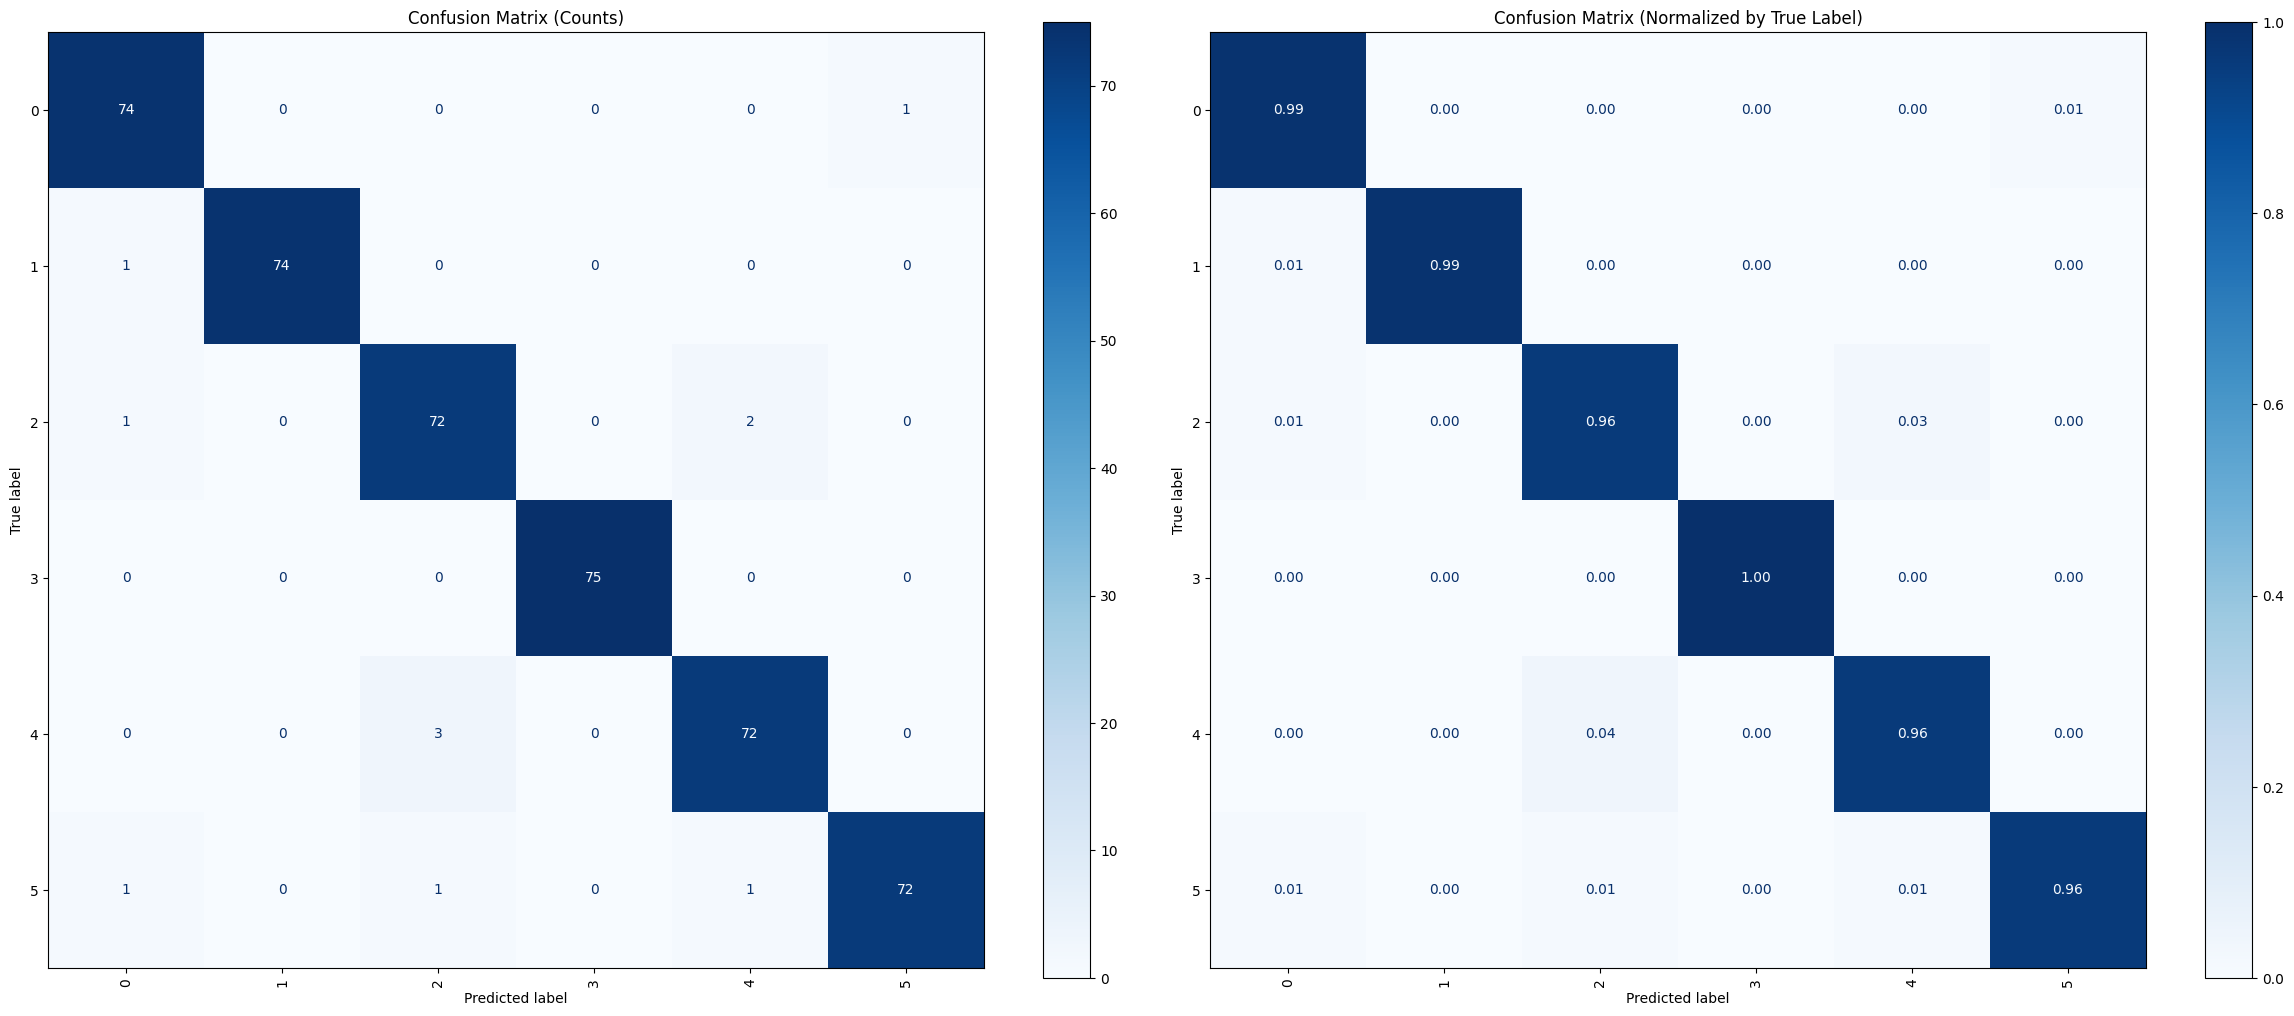

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_split = tokenized_dataset["test"]
predictions, labels_arr, _ = trainer.predict(test_split)
y_pred = np.argmax(predictions, axis=1)
y_true = np.array(labels_arr)

cm = confusion_matrix(y_true, y_pred)
cm_labels = [str(id2label[i]) for i in range(num_labels)]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cm_labels)
disp1.plot(cmap="Blues", ax=axes[0], xticks_rotation=90, values_format="d")
axes[0].set_title("Confusion Matrix (Counts)")

# Normalized (row-wise = recall per class)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=cm_labels)
disp2.plot(cmap="Blues", ax=axes[1], xticks_rotation=90, values_format=".2f")
axes[1].set_title("Confusion Matrix (Normalized by True Label)")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import StratifiedKFold
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, EarlyStoppingCallback
import numpy as np
import torch
import gc
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from scipy import stats
import shutil
import os

n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

all_accuracy_scores = []
all_f1_scores = []
all_precision_scores = []
all_recall_scores = []
all_classification_reports = []

dataset_df = tokenized_dataset["train"].to_pandas()
fold_labels = dataset_df['labels']

num_epochs_cv = 8
grad_accum_steps = 8

for fold, (train_index, val_index) in enumerate(kf.split(dataset_df, fold_labels)):
    folder_path = f"results_fold_{fold+1}"
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)

    print(f"--- Fold {fold+1}/{n_splits} ---")
    
    # Free up memory before initializing the model for the new fold
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    train_dataset_fold = tokenized_dataset["train"].select(train_index)
    val_dataset_fold = tokenized_dataset["train"].select(val_index)

    model_fold = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=num_labels,
        label2id=label2id,
        id2label=id2label,
        attention_dropout=0.0,
        mlp_dropout=0.0,
        embedding_dropout=0.0,
        classifier_dropout=0.0,
    )

    # Warmup fix: account for gradient accumulation in effective batch size
    effective_batch = best_run.hyperparameters["per_device_train_batch_size"] * grad_accum_steps
    steps_per_epoch_fold = len(train_dataset_fold) // effective_batch
    total_steps_fold = steps_per_epoch_fold * num_epochs_cv
    warmup_steps_fold = int(total_steps_fold * 0.1)

    training_args_fold = TrainingArguments(
        output_dir=f"./results_fold_{fold+1}",
        learning_rate=best_run.hyperparameters["learning_rate"],
        per_device_train_batch_size=best_run.hyperparameters["per_device_train_batch_size"],
        per_device_eval_batch_size=4, # Reduced eval batch size further to save memory
        weight_decay=best_run.hyperparameters["weight_decay"],
        gradient_accumulation_steps=grad_accum_steps,
        bf16=True,
        num_train_epochs=num_epochs_cv,
        warmup_steps=warmup_steps_fold,
        lr_scheduler_type="cosine",
        label_smoothing_factor=0.1,
        max_grad_norm=1.0,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        seed=42,
    )

    trainer_fold = Trainer(
        model=model_fold,
        args=training_args_fold,
        train_dataset=train_dataset_fold,
        eval_dataset=val_dataset_fold,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    trainer_fold.train()

    preds_output = trainer_fold.predict(val_dataset_fold)
    y_pred_fold = preds_output.predictions.argmax(axis=-1)
    y_val_fold = preds_output.label_ids

    acc = accuracy_score(y_val_fold, y_pred_fold)
    f1 = f1_score(y_val_fold, y_pred_fold, average="macro")
    prec = precision_score(y_val_fold, y_pred_fold, average="macro")
    rec = recall_score(y_val_fold, y_pred_fold, average="macro")
    report = classification_report(y_val_fold, y_pred_fold, target_names=[str(id2label[i]) for i in range(num_labels)])

    all_accuracy_scores.append(acc)
    all_f1_scores.append(f1)
    all_precision_scores.append(prec)
    all_recall_scores.append(rec)
    all_classification_reports.append(report)

    print(f"Fold {fold+1} — Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    print(report)
    
    # EXPLICIT MEMORY CLEANUP
    del model_fold
    del trainer_fold
    del preds_output
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Clean up the fold directory to save storage space
    if os.path.exists(folder_path):
        try:
            shutil.rmtree(folder_path)
            print(f"Deleted {folder_path} to free storage space.")
        except Exception as e:
            print(f"Could not delete {folder_path}: {e}")

# Overall results with 95% confidence intervals
def ci_95(scores):
    mean = np.mean(scores)
    if len(scores) > 1:
        se = stats.sem(scores)
        ci = stats.t.interval(0.95, df=len(scores)-1, loc=mean, scale=se)
        return mean, ci
    return mean, (mean, mean)

print("\n--- Overall CV Results (mean ± 95% CI) ---")
for name, scores in [("Accuracy", all_accuracy_scores), ("F1-macro", all_f1_scores),
                      ("Precision-macro", all_precision_scores), ("Recall-macro", all_recall_scores)]:
    mean, ci = ci_95(scores)
    print(f"{name}: {mean:.4f}  [{ci[0]:.4f}, {ci[1]:.4f}]")

--- Fold 1/5 ---


Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1321.78it/s, Materializing param=model.layers.21.mlp_norm.weight]     
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,7.892096,0.618750,0.942857,0.943495,0.948465,0.942857
2,4.292735,0.574263,0.935714,0.936356,0.940892,0.935714
3,3.741230,0.548541,0.947619,0.946473,0.949383,0.947619
4,3.500675,0.461537,0.980952,0.980935,0.981016,0.980952
5,3.352890,0.462861,0.983333,0.983331,0.983558,0.983333
6,3.341284,0.462646,0.983333,0.983331,0.983558,0.983333
7,3.339856,0.462596,0.983333,0.983331,0.983558,0.983333
8,3.339556,0.462637,0.983333,0.983331,0.983558,0.983333


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


Fold 1 — Acc: 0.9833 | F1: 0.9833 | Prec: 0.9836 | Rec: 0.9833
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        70
           1       1.00      1.00      1.00        70
           2       0.97      0.96      0.96        70
           3       1.00      1.00      1.00        70
           4       0.96      1.00      0.98        70
           5       1.00      0.97      0.99        70

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420

Deleted results_fold_1 to free storage space.
--- Fold 2/5 ---


...

Fold 4 — Acc: 0.9833 | F1: 0.9834 | Prec: 0.9837 | Rec: 0.9833
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        70
           1       1.00      0.99      0.99        70
           2       0.96      0.99      0.97        70
           3       1.00      1.00      1.00        70
           4       0.99      0.96      0.97        70
           5       1.00      0.99      0.99        70

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420

Deleted results_fold_4 to free storage space.
--- Fold 5/5 ---


Loading weights: 100%|██████████| 136/136 [00:00<00:00, 1330.96it/s, Materializing param=model.layers.21.mlp_norm.weight]     
ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,7.205733,0.757538,0.878571,0.876264,0.907296,0.878571
2,4.115977,0.531875,0.950000,0.950164,0.951048,0.950000
3,3.726635,0.536376,0.952381,0.952240,0.955879,0.952381
4,3.472595,0.504790,0.959524,0.958868,0.961620,0.959524
5,3.392124,0.470827,0.978571,0.978647,0.979209,0.978571
6,3.346020,0.467280,0.980952,0.981016,0.981374,0.980952
7,3.342288,0.467858,0.980952,0.981016,0.981374,0.980952
8,3.341639,0.467678,0.980952,0.981016,0.981374,0.980952


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


Fold 5 — Acc: 0.9810 | F1: 0.9810 | Prec: 0.9814 | Rec: 0.9810
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        70
           1       1.00      1.00      1.00        70
           2       0.95      0.99      0.97        70
           3       1.00      1.00      1.00        70
           4       0.96      0.97      0.96        70
           5       1.00      0.97      0.99        70

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420

Deleted results_fold_5 to free storage space.

--- Overall CV Results (mean ± 95% CI) ---
Accuracy: 0.9805  [0.9741, 0.9869]
F1-macro: 0.9805  [0.9741, 0.9869]
Precision-macro: 0.9809  [0.9747, 0.9870]
Recall-macro: 0.9805  [0.9741, 0.9869]


In [22]:
import shutil

# Download the model
shutil.make_archive("BioClinical_ModernBERT_base_Symptom2Disease_dataset_WITHOUT-DROPOUT", 'zip', "final_model_train")

'/home/notlath/Downloads/model-training/BioClinical_ModernBERT_base_Symptom2Disease_dataset_WITHOUT-DROPOUT.zip'

In [23]:
from transformers import pipeline

classifier = pipeline(
    task="text-classification",
    model="./final_model_train", # Use the fine-tuned model instead of model_id
    tokenizer=tokenizer, # Add the tokenizer
    device=0,
)

# Prompted from ChatGPT to simulate kunwari yung symptoms dedescribe niya ganon
dengue_sample ="I've been hit with a sudden, very high fever that came on a few days ago, and it's making me feel absolutely miserable. I have a throbbing headache that just won't quit, and my eyes hurt, especially behind them. My muscles and joints ache so intensely it feels like my bones are breaking. I'm utterly exhausted, sometimes feel nauseous, and have even thrown up once or twice. To top it all off, I've noticed a red, spotty rash spreading across my skin, and sometimes my gums bleed a little when I brush my teeth."
influenza_sample = "I woke up feeling like a truck hit me. It started with a sudden fever and chills, and now I'm aching all over my body – my muscles, my head, everywhere. I have a terrible dry cough that won't stop, and my throat is really sore. I feel so run down and tired that I can barely get out of bed, and I've completely lost my appetite. I'm also experiencing a lot of congestion and a runny nose, and sometimes I feel a bit dizzy."
typhoid_sample = "I've been dealing with a persistent and gradually worsening fever for about two weeks now, which has left me completely exhausted. It started subtle but has been getting higher each day. I have a constant headache, and my abdomen feels uncomfortably full and painful, sometimes I even get cramps. I'm either constipated or having mild diarrhea. I barely want to eat anything, and I've lost weight. I also feel a bit confused and just generally unwell, like I'm in a haze."
pneumonia_sample = "I've had a really bad cough for over a week now, and it's getting worse, bringing up a lot of thick, yellowish-green mucus. I keep getting high fevers accompanied by severe chills, and I'm sweating through my clothes, especially at night. It's become incredibly difficult to breathe, and I feel constantly short of breath, even when I'm just sitting still. Every time I try to cough or take a deep breath, I get a sharp, stabbing pain in my chest. I'm so weak and fatigued all the time, my appetite is gone, and lately, I've been feeling confused and lightheaded, which is really worrying me."
diarrhea_sample = "For the past day or two, I've had severe, watery diarrhea, and I'm having to run to the bathroom constantly. My stomach is cramping intensely, and I'm experiencing a lot of bloating and gas. I also feel quite nauseous and have vomited a few times. I'm starting to feel really weak and dizzy from losing so many fluids, and I have a dry mouth. I'm worried because the abdominal pain is quite severe, and I haven't been able to keep much food or water down."
measles_sample = "It started a few days ago with a fever, runny nose, sore throat, and a really irritating cough, almost like a bad cold. My eyes are red, watery, and very sensitive to light. Then, about a day or two ago, I noticed tiny white spots, like grains of salt, inside my mouth. Today, a red, blotchy rash appeared on my face, starting near my hairline, and it's now spreading down my neck and body. I feel really unwell and lethargic."

result_1 = classifier(dengue_sample)
result_2 = classifier(pneumonia_sample)
result_3 = classifier(typhoid_sample)
result_4 = classifier(influenza_sample)
result_5 = classifier(measles_sample)
result_6 = classifier(diarrhea_sample)

# Using the mapping from your later cell
disease_mapping = {
    0: "Dengue",
    1: "Diarrhea",
    2: "Influenza",
    3: "Measles",
    4: "Pneumonia",
    5: "Typhoid"
}

results = [result_1, result_2, result_3, result_4, result_5, result_6]
for r in results:
    label_val = r[0]['label']
    # Safely handle string LABEL_k or integer labels
    if isinstance(label_val, str):
        if label_val.startswith("LABEL_"):
            label_id = int(label_val.replace("LABEL_", ""))
        elif label_val.isdigit():
            label_id = int(label_val)
        elif label_val in label2id:
            label_id = label2id[label_val]  # handles labels like "Dengue"
        else:
            raise ValueError(f"Unrecognized label format: {label_val}")
    else:
        label_id = int(label_val)
    # Get the disease name from the mapping
    r[0]['disease'] = disease_mapping.get(label_id, f"Unknown ({label_id})")

tuple(results)

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 1378.47it/s, Materializing param=model.layers.21.mlp_norm.weight]    


([{'label': 0, 'score': 0.8799892067909241, 'disease': 'Dengue'}],
 [{'label': 4, 'score': 0.8785682320594788, 'disease': 'Pneumonia'}],
 [{'label': 5, 'score': 0.7936486005783081, 'disease': 'Typhoid'}],
 [{'label': 2, 'score': 0.9407614469528198, 'disease': 'Influenza'}],
 [{'label': 3, 'score': 0.9786825180053711, 'disease': 'Measles'}],
 [{'label': 1, 'score': 0.9139442443847656, 'disease': 'Diarrhea'}])

# 🔬 Overfitting & Data Integrity Checks

High accuracy can signal either strong generalization or issues (data leakage, overlap, artifacts). This section validates correctness.

**Risks Investigated**
- Data leakage (same text in multiple splits)
- Memorization / overfitting
- Spurious artifacts (format, boilerplate)

**Checks**
1. Text overlap detection between train / validation / test.
2. Full test sweep: predicted vs expected labels (spot anomalies).
3. Qualitative inspection of difficult / long samples.

**Interpretation Guide**
- Zero / near‑zero overlap → split integrity OK.
- Consistently confident & correct predictions → likely real signal; verify class balance.
- If suspicious, consider: stratified splits, adding noise tests, or external validation set.

Outcome: Evidence that performance reflects genuine learning (or flags to address).

In [24]:
for row in dataset['test']:
  result = classifier(row['text'])

  print(f"Row text: {row['text']}")
  print(f"Expected: {id2label[row['labels']]}")
  print(f"Predicted: {result[0]['label']}\n")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Row text: The rapid onset of fever and a harsh, persistent cough have not abated since yesterday. Widespread muscular soreness makes even basic ambulation a painful chore. I am suffering from a relentless, throbbing headache. Swallowing even warm liquids causes localized pharyngeal irritation, and I am utterly exhausted from the lack of restorative sleep.
Expected: 2
Predicted: 2

Row text: The onset occurred five days prior, marked by an inability to perform simple tasks. Initially, I suffered from significant hyperthermia, an unproductive cough, and rhinitis. Subsequently, a maculopapular eruption manifested across my facial region and scalp, which has since descended, covering my torso and abdomen.
Expected: 3
Predicted: 3

Row text: For the past 72 hours, I have been battling hyperpyrexia, a dry cough, nasal congestion, and frequent liquid stools. Subsequently, maculopapular lesions developed at the hairline, descending toward my neck and dorsal region. The cumulative pressure of b

In [25]:
# Function to check for overlaps between two datasets
def check_overlap(dataset1, dataset2, split1_name, split2_name):
    set1 = set(dataset1['text'])
    set2 = set(dataset2['text'])
    overlap = set1.intersection(set2)
    if overlap:
        print(f"Overlap found between {split1_name} and {split2_name}: {len(overlap)} overlapping examples:")
        print(overlap)
    else:
        print(f"No overlap found between {split1_name} and {split2_name}.")

# Check for overlaps between the splits, mukhang isa lang naman yung naging overlap, the rest mukhang completely separate data na so parang ok naman yon i think
check_overlap(dataset['train'], dataset['validation'], 'train', 'validation')
check_overlap(dataset['train'], dataset['test'], 'train', 'test')
check_overlap(dataset['validation'], dataset['test'], 'validation', 'test')

No overlap found between train and validation.
No overlap found between train and test.
No overlap found between validation and test.


### Calibration Analysis

Text(0.5, 1.0, 'Confidence Distribution')

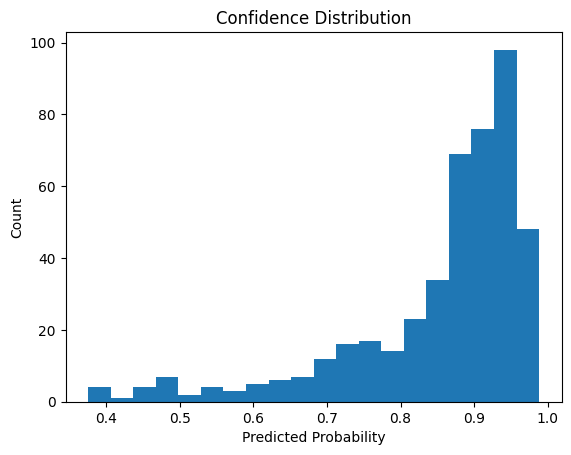

In [26]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import torch

# Get probability scores
probs = torch.softmax(torch.tensor(predictions), dim=-1).numpy()
max_probs = probs.max(axis=1)

# Plot reliability diagram
plt.hist(max_probs, bins=20)
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Confidence Distribution')

### Error Analysis by Symptom Overlap

In [27]:
# Add after confusion matrix
import pandas as pd

# Find most common misclassifications
errors = []
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        errors.append({
            'true': id2label[y_true[i]],
            'predicted': id2label[y_pred[i]],
            'text': dataset['test'][i]['text']
        })

if errors:
    error_df = pd.DataFrame(errors)
    print(error_df['true'].value_counts())
    print("\nMost common confusions:")
    print(error_df.groupby(['true', 'predicted']).size().sort_values(ascending=False).head(10))
else:
    print("No misclassifications found! Perfect accuracy.")

true
4    3
2    3
5    3
1    1
0    1
Name: count, dtype: int64

Most common confusions:
true  predicted
4     2            3
2     4            2
1     0            1
0     5            1
2     0            1
5     0            1
      2            1
      4            1
dtype: int64


# 🧪 Final Evaluation (Test Set)

Evaluate on the held-out test set.

In [28]:
print("Evaluating on Test Set...")
test_results = trainer.predict(tokenized_dataset["test"])
print(test_results.metrics)
print(f"\nTest Accuracy:  {test_results.metrics['test_accuracy']:.4f}")
print(f"Test F1-macro:  {test_results.metrics['test_f1_macro']:.4f}")
print(f"Test Precision: {test_results.metrics['test_precision_macro']:.4f}")
print(f"Test Recall:    {test_results.metrics['test_recall_macro']:.4f}")

Evaluating on Test Set...


{'test_loss': 0.5199580192565918, 'test_accuracy': 0.9755555555555555, 'test_f1_macro': 0.9755980263682127, 'test_precision_macro': 0.9757847919924343, 'test_recall_macro': 0.9755555555555556, 'test_runtime': 1.1348, 'test_samples_per_second': 396.559, 'test_steps_per_second': 50.231}

Test Accuracy:  0.9756
Test F1-macro:  0.9756
Test Precision: 0.9758
Test Recall:    0.9756


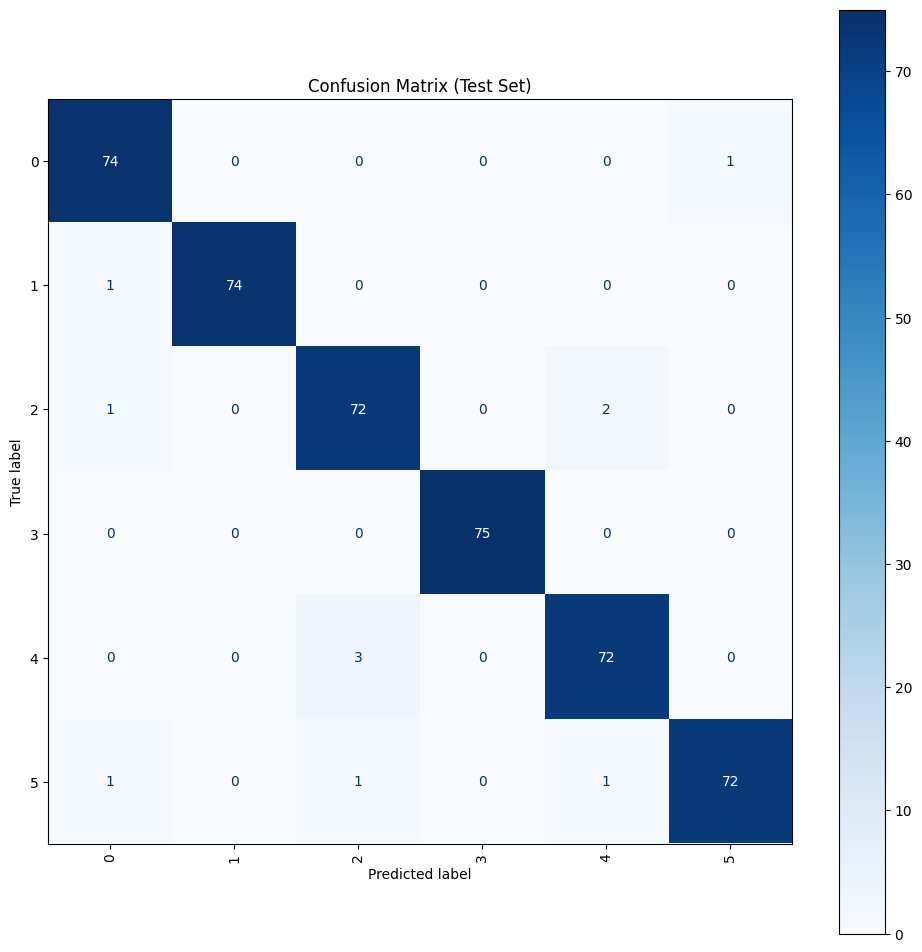

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_results.label_ids
y_pred = test_results.predictions.argmax(axis=1)

# Plot confusion matrix
labels = [str(id2label[i]) for i in range(num_labels)]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# 💾 Save Model

Save the model and tokenizer for future inference.

In [30]:
import json, os

save_path = "./final_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

with open(os.path.join(save_path, "label2id.json"), "w") as f:
    json.dump(label2id, f, indent=2)
with open(os.path.join(save_path, "id2label.json"), "w") as f:
    json.dump(id2label, f, indent=2)

print(f"Model, tokenizer, and label maps saved to {save_path}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]

Model, tokenizer, and label maps saved to ./final_model


In [31]:
from transformers import pipeline

# Load the model directly from the Hugging Face Hub
hf_repo_name = "notlath/BioClinical-ModernBERT-base-Symptom2Disease_WITHOUT-DROPOUT-42"

hf_classifier = pipeline(
    task="text-classification",
    model=hf_repo_name,
    tokenizer=hf_repo_name,
    device=0, # Change to -1 if you are inferencing on CPU
)

# Create a mapping for the labels based on the dataset
disease_mapping = {
    0: "Dengue",
    1: "Diarrhea",
    2: "Influenza",
    3: "Measles",
    4: "Pneumonia",
    5: "Typhoid"
}

def format_prediction(sample_text):
    result = hf_classifier(sample_text)[0]
    raw_label = result["label"]

    if isinstance(raw_label, int):
        label_id = raw_label
    elif isinstance(raw_label, str):
        label_str = raw_label.strip()

        if label_str.startswith("LABEL_"):
            label_id = int(label_str.replace("LABEL_", ""))
        elif label_str.isdigit():
            label_id = int(label_str)
        elif label_str in label2id:
            label_id = label2id[label_str]
        else:
            # Fallback to disease mapping values in case returned label is disease text
            reverse_disease_mapping = {v: k for k, v in disease_mapping.items()}
            if label_str in reverse_disease_mapping:
                label_id = reverse_disease_mapping[label_str]
            else:
                raise ValueError(f"Unrecognized label format: {raw_label}")
    else:
        raise ValueError(f"Unsupported label type: {type(raw_label)}")

    disease = disease_mapping.get(label_id, f"Unknown (ID: {label_id})")
    return f"{disease} ({result['score']:.2%} confidence)"

# Test with some sample symptom descriptions
dengue_sample ="I've been running a sudden, extremely high fever for the past three days that just won't break. My head is throbbing, and there is an intense, sharp pain right behind my eyes every time I look around. My whole body aches so severely that it literally feels like my bones and joints are breaking. On top of all that pain, I've been incredibly nauseous and completely unable to keep any food down. Just a few hours ago, I also noticed tiny red speckles and petechiae appearing on my chest and arms."
influenza_sample = "I woke up feeling like a truck hit me. It started with a sudden fever and chills, and now I'm aching all over my body – my muscles, my head, everywhere. I have a terrible dry cough that won't stop, and my throat is really sore. I feel so run down and tired that I can barely get out of bed, and I've completely lost my appetite. I'm also experiencing a lot of congestion and a runny nose, and sometimes I feel a bit dizzy."
typhoid_sample = "I've been dealing with a persistent and gradually worsening fever for about two weeks now, which has left me completely exhausted. It started subtle but has been getting higher each day. I have a constant headache, and my abdomen feels uncomfortably full and painful, sometimes I even get cramps. I'm either constipated or having mild diarrhea. I barely want to eat anything, and I've lost weight. I also feel a bit confused and just generally unwell, like I'm in a haze."
pneumonia_sample = "I've had a really bad cough for over a week now, and it's getting worse, bringing up a lot of thick, yellowish-green mucus. I keep getting high fevers accompanied by severe chills, and I'm sweating through my clothes, especially at night. It's become incredibly difficult to breathe, and I feel constantly short of breath, even when I'm just sitting still. Every time I try to cough or take a deep breath, I get a sharp, stabbing pain in my chest. I'm so weak and fatigued all the time, my appetite is gone, and lately, I've been feeling confused and lightheaded, which is really worrying me."
diarrhea_sample = "For the past day or two, I've had severe, watery diarrhea, and I'm having to run to the bathroom constantly. My stomach is cramping intensely, and I'm experiencing a lot of bloating and gas. I also feel quite nauseous and have vomited a few times. I'm starting to feel really weak and dizzy from losing so many fluids, and I have a dry mouth. I'm worried because the abdominal pain is quite severe, and I haven't been able to keep much food or water down."
measles_sample = "It started a few days ago with a fever, runny nose, sore throat, and a really irritating cough, almost like a bad cold. My eyes are red, watery, and very sensitive to light. Then, about a day or two ago, I noticed tiny white spots, like grains of salt, inside my mouth. Today, a red, blotchy rash appeared on my face, starting near my hairline, and it's now spreading down my neck and body. I feel really unwell and lethargic."


print("Dengue Prediction:", format_prediction(dengue_sample))
print("Influenza Prediction:", format_prediction(influenza_sample))
print("Typhoid Prediction:", format_prediction(typhoid_sample))
print("Pneumonia Prediction:", format_prediction(pneumonia_sample))
print("Diarrhea Prediction:", format_prediction(diarrhea_sample))
print("Measles Prediction:", format_prediction(measles_sample))

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 1349.29it/s, Materializing param=model.layers.21.mlp_norm.weight]    


Dengue Prediction: Dengue (91.77% confidence)
Influenza Prediction: Influenza (94.08% confidence)
Typhoid Prediction: Typhoid (79.36% confidence)
Pneumonia Prediction: Pneumonia (87.86% confidence)
Diarrhea Prediction: Diarrhea (91.39% confidence)
Measles Prediction: Measles (97.87% confidence)
